# MLP — Day-ahead (72h → 24h) — Gaz/Électricité

Objectif : entraîner un MLP (PyTorch) qui prédit :
- **p** : production électrique des GFPP (24 générateurs)
- **g** : injection de gaz des puits (4 wells dans notre cas)

Contexte “opti / day-ahead” :
- **INPUT** = historique des **72 dernières heures** (3 jours)
- **OUTPUT** = trajectoire du **jour suivant (24h)**

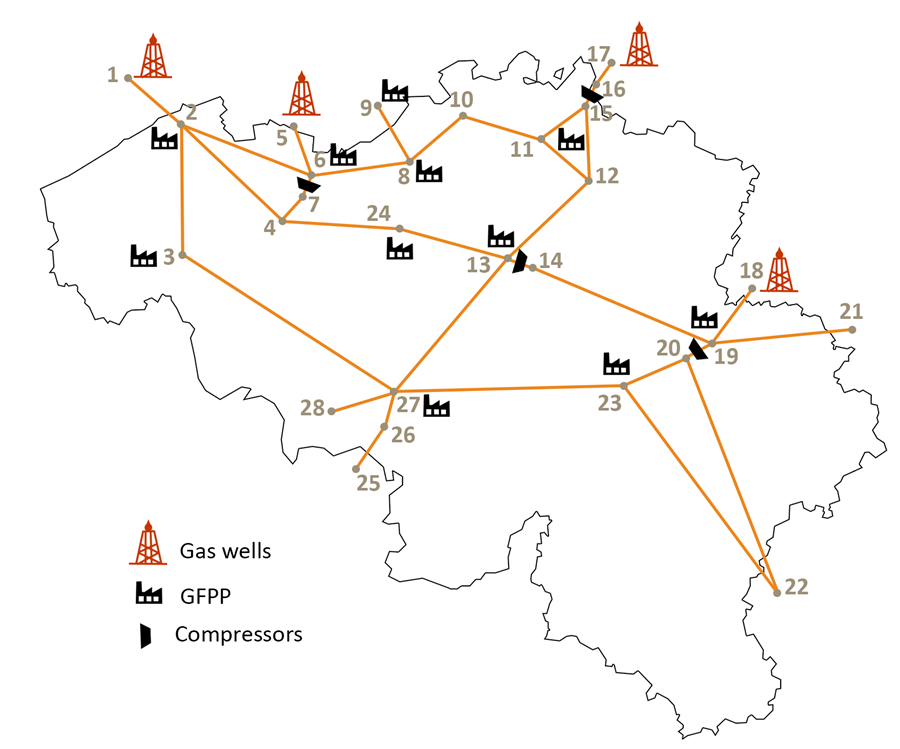

In [1]:
# ============================================================
# CELL 1 — Imports & Paramètres configurables
# ============================================================
import os, re, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")

# ─── Chemins ────────────────────────────────────────────────
DATA_DIR = "."   # adapter si besoin
FILE_OP   = os.path.join(DATA_DIR, "./output/Decision_variablesRU.xlsx")
FILE_ELEC = os.path.join(DATA_DIR, "./input/Elec Load Data.xlsx")
FILE_IND  = os.path.join(DATA_DIR, "./input/Gas Cons Ind.xlsx")
FILE_EXP  = os.path.join(DATA_DIR, "./input/Gas Cons Export.xlsx")
FILE_DIST = os.path.join(DATA_DIR, "./input/Gas Cons Distrib.xlsx")
FILE_NET  = os.path.join(DATA_DIR, "./Gas Network Data.xlsx")

# ─── Hyperparamètres ────────────────────────────────────────
HIST_HOURS    = 72
HORIZON_HOURS = 24
STRIDE_HOURS  = 1
SPLIT_TS      = "2024-11-01 00:00:00"
USE_STATIC    = False

SEED          = 42
BATCH_SIZE    = 64
EPOCHS        = 500
LR            = 1e-4
DROPOUT       = 0.15
HIDDEN_SIZES  = [1024, 1024, 512]
PATIENCE      = 25
LAMBDA_P      = 2.0
LAMBDA_G      = 5.0

OUT_DIR = "./runs_mlp_pg"
os.makedirs(OUT_DIR, exist_ok=True)

print("✓ Cell 1 OK")
print(f"  HIST={HIST_HOURS}h | HORIZON={HORIZON_HOURS}h | STRIDE={STRIDE_HOURS}h")
print(f"  EPOCHS={EPOCHS} | BATCH={BATCH_SIZE} | LR={LR}")
print(f"  LAMBDA_P={LAMBDA_P} | LAMBDA_G={LAMBDA_G}")

✓ Cell 1 OK
  HIST=72h | HORIZON=24h | STRIDE=1h
  EPOCHS=500 | BATCH=64 | LR=0.0001
  LAMBDA_P=2.0 | LAMBDA_G=5.0


In [2]:
# ============================================================
# CELL 2 — Utilitaires
# ============================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def clean_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    unnamed = [c for c in df.columns if str(c).startswith("Unnamed")]
    df = df.drop(columns=unnamed, errors="ignore")
    df = df.select_dtypes(include=[np.number])
    arr = np.nan_to_num(df.values.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    return pd.DataFrame(arr, columns=df.columns)

def rmse_flat(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae_flat(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.abs(y_true - y_pred).mean())

def has_nan(arr: np.ndarray) -> bool:
    return bool(np.isnan(arr).any())

def has_inf(arr: np.ndarray) -> bool:
    return bool(np.isinf(arr).any())

def metrics(true, pred):
    mae  = np.abs(true - pred).mean()
    rmse = np.sqrt(np.mean((true - pred) ** 2))
    rel  = mae / (np.abs(true).mean() + 1e-9) * 100
    r2   = r2_score(true.flatten(), pred.flatten())
    return mae, rmse, rel, r2

set_seed(SEED)
print("✓ Cell 2 OK")

Device : cuda
✓ Cell 2 OK


In [3]:
# ============================================================
# CELL 3 — Chargement des targets p et g
# ============================================================
def _parse_month_sheet(name: str, prefix: str):
    m = re.match(rf"^{prefix}-(\d{{2}})-(\d{{4}})$", name)
    return (m.group(1), m.group(2)) if m else None

def load_targets(filepath: str) -> pd.DataFrame:
    xf = pd.ExcelFile(filepath)
    sheets = xf.sheet_names
    p_months = {_parse_month_sheet(s, "p"): s for s in sheets if _parse_month_sheet(s, "p")}
    g_months = {_parse_month_sheet(s, "g"): s for s in sheets if _parse_month_sheet(s, "g")}
    common   = sorted(set(p_months) & set(g_months))
    print(f"  Mois : {[f'{mo}-{yr}' for mo,yr in common]}")

    frames = []
    for (mo, yr) in common:
        df_p = pd.read_excel(filepath, sheet_name=p_months[(mo, yr)])
        unnamed = [c for c in df_p.columns if str(c).startswith("Unnamed")]
        df_p = df_p.drop(columns=unnamed, errors="ignore")
        df_p = df_p.select_dtypes(include=[np.number]).clip(lower=0)
        arr_p = np.nan_to_num(df_p.values.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
        n_rows = arr_p.shape[0]
        p_cols = [f"p_{i}" for i in range(arr_p.shape[1])]

        df_g = pd.read_excel(filepath, sheet_name=g_months[(mo, yr)])
        unnamed = [c for c in df_g.columns if str(c).startswith("Unnamed")]
        df_g = df_g.drop(columns=unnamed, errors="ignore")
        df_g = df_g.select_dtypes(include=[np.number]).clip(lower=0)
        arr_g = np.nan_to_num(df_g.values.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
        g_cols = [f"g_{i}" for i in range(arr_g.shape[1])]

        ts = pd.date_range(start=pd.Timestamp(f"{yr}-{mo}-01"), periods=n_rows, freq="h")
        df_month = pd.DataFrame(np.hstack([arr_p, arr_g]), columns=p_cols + g_cols)
        df_month.insert(0, "ts", ts)
        frames.append(df_month)

    df_all = pd.concat(frames, ignore_index=True)
    df_all = df_all.sort_values("ts").drop_duplicates("ts").reset_index(drop=True)
    return df_all

print("Chargement targets ...")
df_pg_all  = load_targets(FILE_OP)
p_cols_all = [c for c in df_pg_all.columns if c.startswith("p_")]
g_cols_all = [c for c in df_pg_all.columns if c.startswith("g_")]

print(f"\n✓ df_pg_all : {df_pg_all.shape}")
print(f"  ts : {df_pg_all['ts'].min()} → {df_pg_all['ts'].max()}")
print(f"  p cols : {len(p_cols_all)} | g cols : {len(g_cols_all)}")

Chargement targets ...
  Mois : ['01-2024', '02-2024', '03-2024', '04-2024', '05-2024', '06-2024', '07-2024', '08-2024', '09-2024', '10-2024', '11-2024', '12-2024']

✓ df_pg_all : (8784, 29)
  ts : 2024-01-01 00:00:00 → 2024-12-31 23:00:00
  p cols : 24 | g cols : 4


In [4]:
# ============================================================
# CELL 4 — Chargement des consommations (inputs dynamiques)
# ============================================================
def _valid_month_sheet(name: str) -> bool:
    return bool(re.match(r"^\d{2}-\d{4}$", name))

def load_cons_file(filepath, dt_col, value_cols, prefix, month_keys):
    xf = pd.ExcelFile(filepath)
    frames = []
    for sheet in xf.sheet_names:
        if not _valid_month_sheet(sheet) or sheet not in month_keys:
            continue
        df = pd.read_excel(filepath, sheet_name=sheet)
        unnamed = [c for c in df.columns if str(c).startswith("Unnamed")]
        df = df.drop(columns=unnamed, errors="ignore")
        df["ts"] = pd.to_datetime(df[dt_col], errors="coerce")
        df = df.dropna(subset=["ts"])
        if value_cols is None:
            cols_keep = df.select_dtypes(include=[np.number]).columns.tolist()
        else:
            cols_keep = [c for c in value_cols if c in df.columns]
        frames.append(df[["ts"] + cols_keep].copy())

    if not frames:
        return pd.DataFrame(columns=["ts"])
    df_all = pd.concat(frames, ignore_index=True)
    df_all = df_all.sort_values("ts").drop_duplicates("ts").reset_index(drop=True)
    df_all = df_all.rename(columns={c: f"{prefix}{c}" for c in df_all.columns if c != "ts"})
    return df_all

month_keys = set(df_pg_all["ts"].dt.strftime("%m-%Y").unique())

df_elec = load_cons_file(FILE_ELEC, "Datetime",
    ["Measured & Upscaled [MW]"], "elec__", month_keys)
df_ind  = load_cons_file(FILE_IND,  "Date Time",
    ["Physical Flow (kWh)", "Physical Flow (MNm3)", "GCV (kwh/Nm3)"], "gas_ind__", month_keys)
df_exp  = load_cons_file(FILE_EXP,  "Date Time", None, "gas_exp__", month_keys)
df_dist = load_cons_file(FILE_DIST, "Date Time",
    ["Physical Flow (kWh)", "Physical Flow (MNm3)", "GCV (kwh/Nm3)"], "gas_dist__", month_keys)

print(f"  Elec:{df_elec.shape} | Ind:{df_ind.shape} | Exp:{df_exp.shape} | Dist:{df_dist.shape}")

cons_all = df_pg_all[["ts"]].copy()
for df_src in [df_elec, df_ind, df_exp, df_dist]:
    if df_src.shape[1] > 1:
        cons_all = cons_all.merge(df_src, on="ts", how="left")

feat_cols = [c for c in cons_all.columns if c != "ts"]
cons_all[feat_cols] = (
    cons_all[feat_cols]
    .interpolate(method="linear", limit_direction="both")
    .fillna(0)
)
cons_all[feat_cols] = np.nan_to_num(
    cons_all[feat_cols].values.astype(np.float32),
    nan=0.0, posinf=0.0, neginf=0.0
)

print(f"\n✓ cons_all : {cons_all.shape} | features : {len(feat_cols)}")
print(f"  Any NaN : {cons_all[feat_cols].isna().any().any()}")

  Elec:(8784, 2) | Ind:(8784, 4) | Exp:(8784, 7) | Dist:(8784, 4)

✓ cons_all : (8784, 14) | features : 13
  Any NaN : False


In [5]:
# ============================================================
# CELL 5 — Vecteur statique réseau
# ============================================================
def load_static_vector(filepath: str) -> dict:
    parts = []
    df_nodes = pd.read_excel(filepath, sheet_name="Nodes")
    node_cols = [c for c in ["Res_Load_share_%","Ind_Load_share_%","Exp_Load_share_%",
                              "Pr_min [bar]","Pr_max [bar]"] if c in df_nodes.columns]
    parts.append(df_nodes[node_cols].values.astype(np.float32).flatten())

    df_pip = pd.read_excel(filepath, sheet_name="Pipelines")
    pip_cols = [c for c in ["Natural gas flow constant [MNm3/(bar*h)2]","Compressor factor",
                             "High Linepack","Initial linepack [MNm3]",
                             "Linepack constant [MNm3/bar]"] if c in df_pip.columns]
    parts.append(df_pip[pip_cols].values.astype(np.float32).flatten())

    df_well = pd.read_excel(filepath, sheet_name="Well")
    well_cols = [c for c in ["Gmax [MNm3/h]","Day-ahead offer price [€/MNm3]"]
                 if c in df_well.columns]
    parts.append(df_well[well_cols].values.astype(np.float32).flatten())

    df_gwm = pd.read_excel(filepath, sheet_name="GasWellMap")
    parts.append(df_gwm.select_dtypes(include=[np.number]).values.astype(np.float32).flatten())

    df_gm = pd.read_excel(filepath, sheet_name="GFPPMap")
    parts.append(df_gm.select_dtypes(include=[np.number]).values.astype(np.float32).flatten())

    vec = np.nan_to_num(np.concatenate(parts), nan=0.0, posinf=0.0, neginf=0.0)
    return {"static_vec": vec, "static_dim": len(vec)}

if USE_STATIC:
    static = load_static_vector(FILE_NET)
    print(f"✓ Static dim : {static['static_dim']}")
else:
    static = {"static_vec": np.zeros(0, dtype=np.float32), "static_dim": 0}
    print("✓ Cell 5 OK — USE_STATIC=False")

✓ Cell 5 OK — USE_STATIC=False


In [6]:
# ============================================================
# CELL 6 — Construction des fenêtres (autorégressif p+g)
# ============================================================
def build_windows(df_pg, cons, static_vec, hist_hours, horizon_hours, stride, use_static):
    p_cols    = [c for c in df_pg.columns if c.startswith("p_")]
    g_cols    = [c for c in df_pg.columns if c.startswith("g_")]
    feat_cols = [c for c in cons.columns  if c != "ts"]

    P = len(p_cols); G = len(g_cols); D = len(feat_cols)
    p_dim = P * horizon_hours
    g_dim = G * horizon_hours

    arr_ts   = df_pg["ts"].values
    arr_p    = df_pg[p_cols].values.astype(np.float32)
    arr_g    = df_pg[g_cols].values.astype(np.float32)
    arr_cons = cons[feat_cols].values.astype(np.float32)
    T = len(arr_ts)

    ts_pd   = pd.DatetimeIndex(arr_ts)
    diffs   = ts_pd[1:] - ts_pd[:-1]
    gap_idx = set(np.where(diffs != pd.Timedelta(hours=1))[0] + 1)

    def has_gap(start, end):
        return any((start <= g < end) for g in gap_idx)

    Xs, ys, tss = [], [], []

    for t0 in range(hist_hours, T - horizon_hours + 1, stride):
        ws = t0 - hist_hours
        we = t0 + horizon_hours
        if has_gap(ws, we):
            continue

        x_cons   = arr_cons[ws:t0].reshape(-1)
        x_p_hist = arr_p[ws:t0].reshape(-1)
        x_g_hist = arr_g[ws:t0].reshape(-1)
        x = np.concatenate([x_cons, x_p_hist, x_g_hist])
        if use_static and len(static_vec) > 0:
            x = np.concatenate([x, static_vec])

        y_p = arr_p[t0:t0 + horizon_hours].reshape(-1)
        y_g = arr_g[t0:t0 + horizon_hours].reshape(-1)

        Xs.append(x)
        ys.append(np.concatenate([y_p, y_g]))
        tss.append(arr_ts[t0])

    X      = np.stack(Xs).astype(np.float32)
    y      = np.stack(ys).astype(np.float32)
    win_ts = np.array(tss)

    x_dim = hist_hours * (D + P + G) + (static_vec.shape[0] if use_static else 0)
    meta  = {"X_dim": x_dim, "y_dim": p_dim+g_dim,
             "p_dim": p_dim, "g_dim": g_dim,
             "dyn_per_hour": D, "P": P, "G": G}
    return X, y, win_ts, meta

print("Construction des fenêtres ...")
X, y, win_ts, meta = build_windows(
    df_pg_all, cons_all, static["static_vec"],
    HIST_HOURS, HORIZON_HOURS, STRIDE_HOURS, USE_STATIC
)
p_dim = meta["p_dim"]
g_dim = meta["g_dim"]

print(f"\n✓ Cell 6 OK")
print(f"  X : {X.shape} | y : {y.shape}")
print(f"  p_dim={p_dim} | g_dim={g_dim} | X_dim={meta['X_dim']}")
print(f"  NaN X:{has_nan(X)} Inf X:{has_inf(X)} | NaN y:{has_nan(y)} Inf y:{has_inf(y)}")

Construction des fenêtres ...

✓ Cell 6 OK
  X : (8689, 2952) | y : (8689, 672)
  p_dim=576 | g_dim=96 | X_dim=2952
  NaN X:False Inf X:False | NaN y:False Inf y:False


In [7]:
# ============================================================
# CELL 6 — Construction des fenêtres (autorégressif p+g)
# ============================================================
def build_windows(df_pg, cons, static_vec, hist_hours, horizon_hours, stride, use_static):
    p_cols    = [c for c in df_pg.columns if c.startswith("p_")]
    g_cols    = [c for c in df_pg.columns if c.startswith("g_")]
    feat_cols = [c for c in cons.columns  if c != "ts"]

    P = len(p_cols); G = len(g_cols); D = len(feat_cols)
    p_dim = P * horizon_hours
    g_dim = G * horizon_hours

    arr_ts   = df_pg["ts"].values
    arr_p    = df_pg[p_cols].values.astype(np.float32)
    arr_g    = df_pg[g_cols].values.astype(np.float32)
    arr_cons = cons[feat_cols].values.astype(np.float32)
    T = len(arr_ts)

    ts_pd   = pd.DatetimeIndex(arr_ts)
    diffs   = ts_pd[1:] - ts_pd[:-1]
    gap_idx = set(np.where(diffs != pd.Timedelta(hours=1))[0] + 1)

    def has_gap(start, end):
        return any((start <= g < end) for g in gap_idx)

    Xs, ys, tss = [], [], []

    for t0 in range(hist_hours, T - horizon_hours + 1, stride):
        ws = t0 - hist_hours
        we = t0 + horizon_hours
        if has_gap(ws, we):
            continue

        x_cons   = arr_cons[ws:t0].reshape(-1)
        x_p_hist = arr_p[ws:t0].reshape(-1)
        x_g_hist = arr_g[ws:t0].reshape(-1)
        x = np.concatenate([x_cons, x_p_hist, x_g_hist])

        if use_static and len(static_vec) > 0:
            x = np.concatenate([x, static_vec])

        y_p = arr_p[t0:t0 + horizon_hours].reshape(-1)
        y_g = arr_g[t0:t0 + horizon_hours].reshape(-1)

        Xs.append(x)
        ys.append(np.concatenate([y_p, y_g]))
        tss.append(arr_ts[t0])

    X      = np.stack(Xs).astype(np.float32)
    y      = np.stack(ys).astype(np.float32)
    win_ts = np.array(tss)

    x_dim = hist_hours * (D + P + G) + (static_vec.shape[0] if use_static else 0)
    meta  = {
        "X_dim": x_dim,
        "y_dim": p_dim + g_dim,
        "p_dim": p_dim,
        "g_dim": g_dim,
        "dyn_per_hour": D,
        "P": P,
        "G": G
    }
    return X, y, win_ts, meta

print("Construction des fenêtres ...")
X, y, win_ts, meta = build_windows(
    df_pg_all, cons_all, static["static_vec"],
    HIST_HOURS, HORIZON_HOURS, STRIDE_HOURS, USE_STATIC
)
p_dim = meta["p_dim"]
g_dim = meta["g_dim"]

print(f"\n✓ Cell 6 OK")
print(f"  X : {X.shape} | y : {y.shape}")
print(f"  p_dim={p_dim} | g_dim={g_dim} | X_dim={meta['X_dim']}")
print(f"  NaN X:{has_nan(X)} Inf X:{has_inf(X)} | NaN y:{has_nan(y)} Inf y:{has_inf(y)}")

Construction des fenêtres ...

✓ Cell 6 OK
  X : (8689, 2952) | y : (8689, 672)
  p_dim=576 | g_dim=96 | X_dim=2952
  NaN X:False Inf X:False | NaN y:False Inf y:False


In [8]:
# ============================================================
# CELL 7 — Train / Val split
# ============================================================
split_ts  = pd.Timestamp(SPLIT_TS)
win_ts_pd = pd.DatetimeIndex(win_ts)

train_mask = win_ts_pd < split_ts
val_mask   = win_ts_pd >= split_ts

X_train, y_train, ts_train = X[train_mask], y[train_mask], win_ts[train_mask]
X_val,   y_val,   ts_val   = X[val_mask],   y[val_mask],   win_ts[val_mask]

print(f"✓ Cell 7 OK — Split : {SPLIT_TS}")
print(f"  Train : N={X_train.shape[0]} | {pd.Timestamp(ts_train[0]).date()} → {pd.Timestamp(ts_train[-1]).date()}")
print(f"  Val   : N={X_val.shape[0]}   | {pd.Timestamp(ts_val[0]).date()} → {pd.Timestamp(ts_val[-1]).date()}")
print(f"  Ratio val : {len(X_val)/(len(X_train)+len(X_val))*100:.1f}%")

✓ Cell 7 OK — Split : 2024-11-01 00:00:00
  Train : N=7248 | 2024-01-04 → 2024-10-31
  Val   : N=1441   | 2024-11-01 → 2024-12-31
  Ratio val : 16.6%


In [9]:
# ============================================================
# CELL 8 — Normalisation séparée X, p, g
# ============================================================
scaler_X   = StandardScaler()
scaler_y_p = StandardScaler()
scaler_y_g = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler_X.transform(X_val).astype(np.float32)

y_train_p = y_train[:, :p_dim];  y_train_g = y_train[:, p_dim:]
y_val_p   = y_val[:, :p_dim];    y_val_g   = y_val[:, p_dim:]

y_train_p_s = scaler_y_p.fit_transform(y_train_p)
y_train_g_s = scaler_y_g.fit_transform(y_train_g)
y_val_p_s   = scaler_y_p.transform(y_val_p)
y_val_g_s   = scaler_y_g.transform(y_val_g)

y_train_s = np.hstack([y_train_p_s, y_train_g_s]).astype(np.float32)
y_val_s   = np.hstack([y_val_p_s,   y_val_g_s  ]).astype(np.float32)

joblib.dump(scaler_X,   os.path.join(OUT_DIR, "scaler_X.pkl"))
joblib.dump(scaler_y_p, os.path.join(OUT_DIR, "scaler_y_p.pkl"))
joblib.dump(scaler_y_g, os.path.join(OUT_DIR, "scaler_y_g.pkl"))

print("✓ Cell 8 OK — Scalers sauvegardés")
print(f"  X_train_s : {X_train_s.shape} | X_val_s : {X_val_s.shape}")

✓ Cell 8 OK — Scalers sauvegardés
  X_train_s : (7248, 2952) | X_val_s : (1441, 2952)


In [10]:
# ============================================================
# CELL 9 — Poids par sortie (avec boost GFPP outliers)
# ============================================================
def output_weights(y_scaled: np.ndarray) -> torch.Tensor:
    mean_abs = np.abs(y_scaled).mean(axis=0) + 1e-3
    w = 1.0 / mean_abs
    w = w / w.sum() * len(w)
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

y_p_weights = output_weights(y_train_p_s)
y_g_weights = output_weights(y_train_g_s)

#BOOST_GFPPS = {5: 3.0, 21: 3.0, 2: 2.0}
#P_meta = meta["P"]
#w_p = y_p_weights.clone()
#for gfpp_idx, boost in BOOST_GFPPS.items():
    #indices = [h * P_meta + gfpp_idx for h in range(HORIZON_HOURS)]
    #w_p[indices] *= boost
#w_p = w_p / w_p.sum() * len(w_p)
#y_p_weights = w_p

#print("✓ Cell 9 OK")
#print(f"  y_p_weights : min={y_p_weights.min():.4f} max={y_p_weights.max():.4f}")
#print(f"  y_g_weights : min={y_g_weights.min():.4f} max={y_g_weights.max():.4f}")
#print(f"  Boost GFPPs : {BOOST_GFPPS}")

In [11]:
# ============================================================
# CELL 10 — Dataset & DataLoaders
# ============================================================
class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(NumpyDataset(X_train_s, y_train_s),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=False,
    num_workers=0, pin_memory=(DEVICE=="cuda"))
val_loader = DataLoader(NumpyDataset(X_val_s, y_val_s),
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False,
    num_workers=0, pin_memory=(DEVICE=="cuda"))

print(f"✓ Cell 10 OK")
print(f"  Train batches : {len(train_loader)} | Val batches : {len(val_loader)}")

✓ Cell 10 OK
  Train batches : 114 | Val batches : 23


In [12]:
# ============================================================
# CELL 11 — Architecture MLP classique (single head)
# ============================================================
class MLP(nn.Module):
    """
    MLP standard : empilement de couches Linear → BatchNorm → ReLU → Dropout
    Une seule tête de sortie → (p_dim + g_dim)
    """
    def __init__(self, x_dim, out_dim, hidden_sizes, dropout):
        super().__init__()
        layers = []
        in_dim = x_dim
        for h in hidden_sizes:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, out_dim))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

set_seed(SEED)
model = MLP(
    x_dim       = meta["X_dim"],
    out_dim     = p_dim + g_dim,
    hidden_sizes= HIDDEN_SIZES,
    dropout     = DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Cell 11 OK — MLP classique")
print(f"  X_dim={meta['X_dim']} | out_dim={p_dim+g_dim} | params={n_params:,}")
print(model)

✓ Cell 11 OK — MLP classique
  X_dim=2952 | out_dim=672 | params=4,948,128
MLP(
  (net): Sequential(
    (0): Linear(in_features=2952, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=1024, out_features=1024, bias=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=1024, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=512, out_features=672, bias=True)
  )
)


In [13]:
# ============================================================
# CELL 12 — Entraînement (Adam + Huber pondérée)
# ============================================================
criterion = nn.MSELoss(reduction="none")
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=15, min_lr=1e-6
)

def weighted_mse_loss(pred, target, weights,
                      zero_penalty=2.0, zero_thresh=0.1):
    loss = criterion(pred, target)   # (pred-target)^2 élément par élément
    is_zero = target.abs() < zero_thresh
    is_fp   = is_zero & (pred.abs() > zero_thresh)
    loss = loss * (1.0 + (zero_penalty - 1.0) * is_fp.float())
    return (loss * weights).mean()

def run_epoch(loader, training):
    model.train(training)
    total_loss = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            pred   = model(Xb)
            loss_p = weighted_mse_loss(pred[:,:p_dim], yb[:,:p_dim], y_p_weights)
            loss_g = weighted_mse_loss(pred[:,p_dim:], yb[:,p_dim:], y_g_weights)
            loss   = loss_p + loss_g
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            total_loss += loss.item() * len(Xb)
    return total_loss / len(loader.dataset)

best_val   = float("inf")
patience_c = 0
best_path  = os.path.join(OUT_DIR, "best_model.pt")
history    = {"train": [], "val": [], "lr": []}

print(f"{'Epoch':>6} | {'Train':>10} | {'Val':>10} | {'Best':>10} | {'Pat':>4} | {'LR':>10}")
print("-" * 62)

for epoch in range(1, EPOCHS + 1):
    tr  = run_epoch(train_loader, True)
    val = run_epoch(val_loader,   False)
    scheduler.step(val)
    history["train"].append(tr)
    history["val"].append(val)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if val < best_val - 1e-4 and epoch > 15 :
        best_val = val; patience_c = 0
        torch.save(model.state_dict(), best_path)
    else:
        patience_c += 1

    if epoch % 5 == 0:
        lr = optimizer.param_groups[0]["lr"]
        print(f"{epoch:>6} | {tr:>10.5f} | {val:>10.5f} | "
              f"{best_val:>10.5f} | {patience_c:>4} | {lr:>10.2e}")

    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            ps = model(torch.from_numpy(X_val_s).to(DEVICE)).cpu().numpy()
        mae_p = np.abs(scaler_y_p.inverse_transform(ps[:,:p_dim]) - y_val_p).mean()
        mae_g = np.abs(scaler_y_g.inverse_transform(ps[:,p_dim:]) - y_val_g).mean()
        print(f"         → MAE réel  p={mae_p:.2f} MW | g={mae_g:.5f} MNm3/h")

    if patience_c >= PATIENCE:
        print(f"\n⚡ Early stopping epoch {epoch}")
        break

print(f"\n✓ Entraînement terminé — best val={best_val:.6f}")

 Epoch |      Train |        Val |       Best |  Pat |         LR
--------------------------------------------------------------
     5 |    1.41172 |    2.48984 |        inf |    5 |   1.00e-04
    10 |    1.15144 |    2.50399 |        inf |   10 |   1.00e-04
         → MAE réel  p=0.80 MW | g=0.30497 MNm3/h
    15 |    0.99435 |    2.46086 |        inf |   15 |   1.00e-04
    20 |    0.89967 |    2.39879 |    2.39879 |    0 |   1.00e-04
         → MAE réel  p=0.74 MW | g=0.30259 MNm3/h
    25 |    0.83687 |    2.45556 |    2.34296 |    2 |   1.00e-04
    30 |    0.79556 |    2.43261 |    2.34296 |    7 |   1.00e-04
         → MAE réel  p=0.70 MW | g=0.30546 MNm3/h
    35 |    0.75822 |    2.43741 |    2.34296 |   12 |   1.00e-04
    40 |    0.70997 |    2.42874 |    2.34296 |   17 |   5.00e-05
         → MAE réel  p=0.75 MW | g=0.29484 MNm3/h
    45 |    0.69011 |    2.45685 |    2.34296 |   22 |   5.00e-05

⚡ Early stopping epoch 48

✓ Entraînement terminé — best val=2.342965


In [16]:
# ============================================================
# CELL 13 — Prédictions finales (meilleur modèle)
# ============================================================
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

with torch.no_grad():
    pred_s = model(torch.from_numpy(X_val_s).to(DEVICE)).cpu().numpy()

y_val_pred_p = np.clip(scaler_y_p.inverse_transform(pred_s[:, :p_dim]), 0, None)
y_val_pred_g = np.clip(scaler_y_g.inverse_transform(pred_s[:, p_dim:]), 0, None)
y_val_true_p = y_val_p
y_val_true_g = y_val_g

y_val_true = np.hstack([y_val_true_p, y_val_true_g])
y_val_pred = np.hstack([y_val_pred_p, y_val_pred_g])

# Reshape 3D (N, HZ, unités)
P_  = meta["P"]; G_ = meta["G"]; HZ = HORIZON_HOURS
p_true_3d = y_val_true_p.reshape(-1, HZ, P_)
p_pred_3d = y_val_pred_p.reshape(-1, HZ, P_)
g_true_3d = y_val_true_g.reshape(-1, HZ, G_)
g_pred_3d = y_val_pred_g.reshape(-1, HZ, G_)

p_total_true = p_true_3d.sum(-1)   # (N, 24)
p_total_pred = p_pred_3d.sum(-1)
g_total_true = g_true_3d.sum(-1)
g_total_pred = g_pred_3d.sum(-1)

mae_p,  rmse_p,  rel_p,  r2_p  = metrics(y_val_true_p, y_val_pred_p)
mae_g,  rmse_g,  rel_g,  r2_g  = metrics(y_val_true_g, y_val_pred_g)
mae_pt, rmse_pt, rel_pt, r2_pt = metrics(p_total_true,  p_total_pred)
mae_gt, rmse_gt, rel_gt, r2_gt = metrics(g_total_true,  g_total_pred)

print("=" * 65)
print("=== GLOBAL METRICS ===")
print(f"  p: MAE={mae_p:.2f} MW  | RMSE={rmse_p:.2f} | MAPE={rel_p:.1f}% | R²={r2_p:.4f}")
print(f"  g: MAE={mae_g:.5f}    | RMSE={rmse_g:.5f} | MAPE={rel_g:.1f}% | R²={r2_g:.4f}")
print("=== TOTAUX AGRÉGÉS ===")
print(f"  p_total: MAE={mae_pt:.2f} MW | RMSE={rmse_pt:.2f} | MAPE={rel_pt:.1f}% | R²={r2_pt:.4f}")
print(f"  g_total: MAE={mae_gt:.5f}   | RMSE={rmse_gt:.5f} | MAPE={rel_gt:.1f}% | R²={r2_gt:.4f}")
print("=" * 65)

=== GLOBAL METRICS ===
  p: MAE=0.71 MW  | RMSE=1.29 | MAPE=26.3% | R²=0.9245
  g: MAE=0.29640    | RMSE=0.38678 | MAPE=22.7% | R²=0.8348
=== TOTAUX AGRÉGÉS ===
  p_total: MAE=9.91 MW | RMSE=12.59 | MAPE=15.2% | R²=0.3312
  g_total: MAE=0.75317   | RMSE=0.96869 | MAPE=14.4% | R²=0.3458


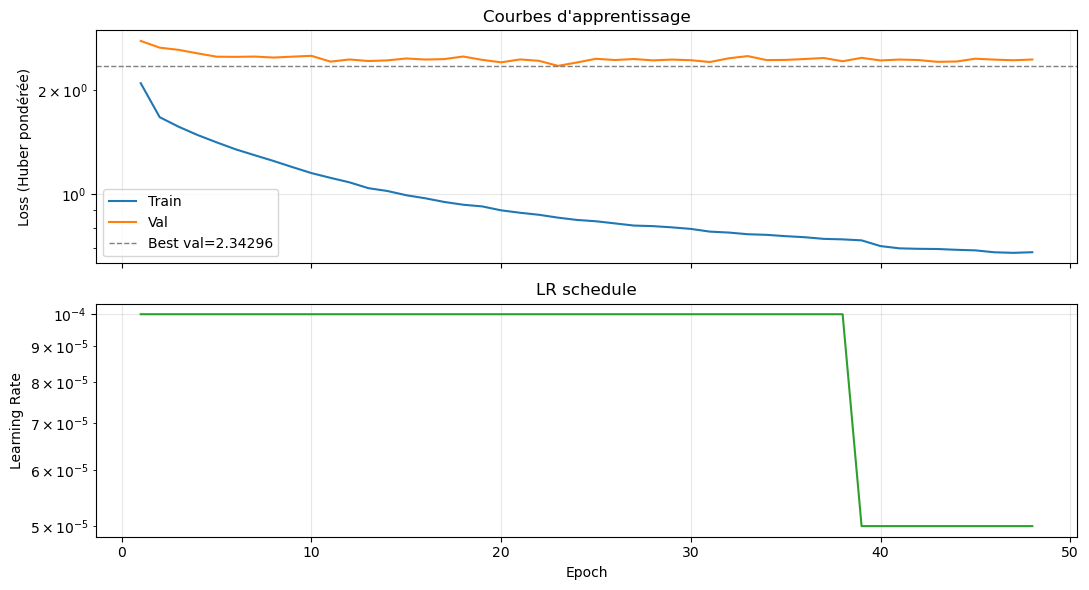

In [17]:
# ============================================================
# CELL 14 — Plot : Courbes d'apprentissage + LR schedule
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

epochs_x = range(1, len(history["train"]) + 1)

ax1.plot(epochs_x, history["train"], label="Train", lw=1.5, color="#1f77b4")
ax1.plot(epochs_x, history["val"],   label="Val",   lw=1.5, color="#ff7f0e")
ax1.axhline(min(history["val"]), color="gray", lw=1, ls="--",
            label=f"Best val={min(history['val']):.5f}")
ax1.set_ylabel("Loss (Huber pondérée)")
ax1.set_title("Courbes d'apprentissage")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_yscale("log")

ax2.plot(epochs_x, history["lr"], lw=1.5, color="#2ca02c")
ax2.set_ylabel("Learning Rate")
ax2.set_xlabel("Epoch")
ax2.set_title("LR schedule")
ax2.grid(True, alpha=0.3)
ax2.set_yscale("log")

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "01_learning_curves.png"), dpi=130, bbox_inches="tight")
plt.show()

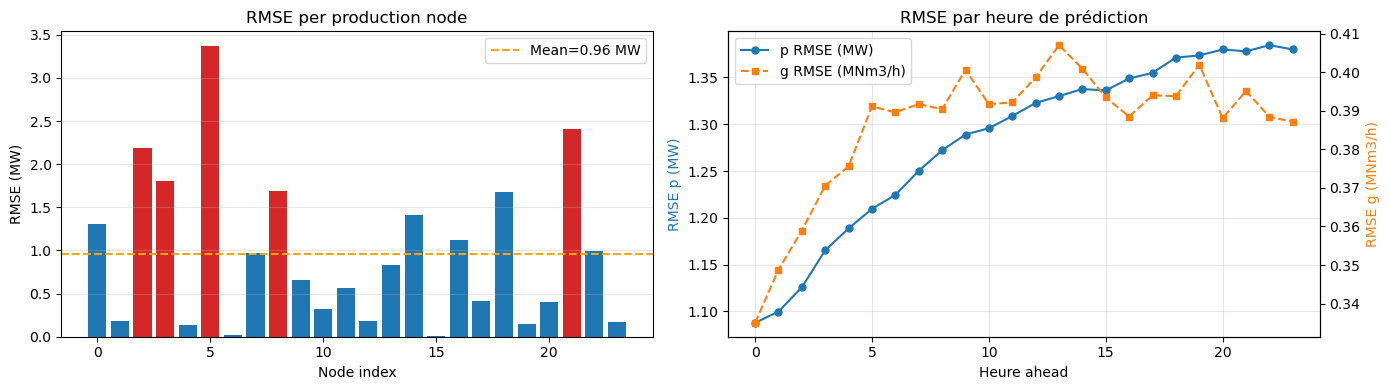

In [18]:
# ============================================================
# CELL 15 — Plot : RMSE par GFPP + RMSE par heure ahead
# ============================================================
rmse_per_gfpp  = np.sqrt(np.mean((p_pred_3d - p_true_3d)**2, axis=(0,1)))  # (P,)
rmse_per_hour_p = np.sqrt(np.mean((p_pred_3d - p_true_3d)**2, axis=(0,2)))  # (24,)
rmse_per_hour_g = np.sqrt(np.mean((g_pred_3d - g_true_3d)**2, axis=(0,2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ["#d62728" if r > np.percentile(rmse_per_gfpp, 80) else "#1f77b4"
          for r in rmse_per_gfpp]
axes[0].bar(range(P_), rmse_per_gfpp, color=colors)
axes[0].set_xlabel("Node index"); axes[0].set_ylabel("RMSE (MW)")
axes[0].set_title("RMSE per production node")
axes[0].axhline(rmse_per_gfpp.mean(), color="orange", lw=1.5, ls="--",
                label=f"Mean={rmse_per_gfpp.mean():.2f} MW")
axes[0].legend(); axes[0].grid(True, axis="y", alpha=0.3)

ax2 = axes[1]
ax2.plot(range(HZ), rmse_per_hour_p, label="p RMSE (MW)", marker="o", ms=5, color="#1f77b4")
ax2_r = ax2.twinx()
ax2_r.plot(range(HZ), rmse_per_hour_g, label="g RMSE (MNm3/h)", marker="s",
           ms=5, color="#ff7f0e", ls="--")
ax2.set_xlabel("Heure ahead"); ax2.set_ylabel("RMSE p (MW)", color="#1f77b4")
ax2_r.set_ylabel("RMSE g (MNm3/h)", color="#ff7f0e")
ax2.set_title("RMSE par heure de prédiction")
ax2.grid(True, alpha=0.3)
lines1, l1 = ax2.get_legend_handles_labels()
lines2, l2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1+lines2, l1+l2, loc="upper left")

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "02_rmse_diagnostics.png"), dpi=130, bbox_inches="tight")
plt.show()

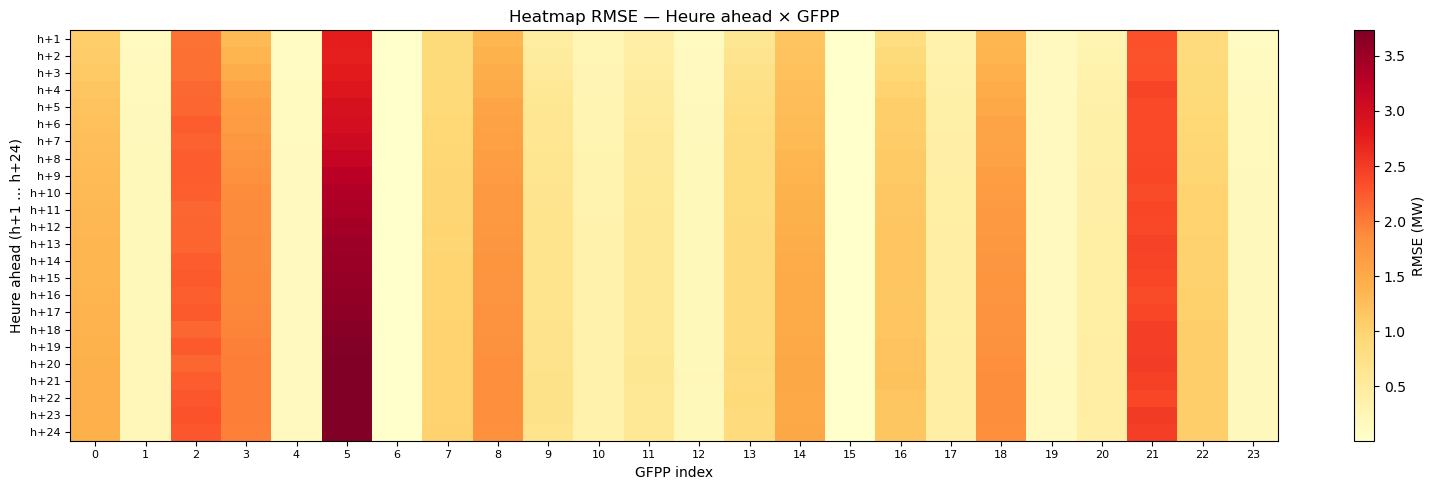

In [19]:
# ============================================================
# CELL 16 — Plot : Heatmap RMSE GFPP × Heure ahead
# ============================================================
rmse_heatmap = np.sqrt(np.mean((p_pred_3d - p_true_3d)**2, axis=0))  # (HZ, P)

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(rmse_heatmap, aspect="auto", cmap="YlOrRd", origin="upper")
plt.colorbar(im, ax=ax, label="RMSE (MW)")
ax.set_xlabel("GFPP index")
ax.set_ylabel("Heure ahead (h+1 … h+24)")
ax.set_title("Heatmap RMSE — Heure ahead × GFPP")
ax.set_xticks(range(P_)); ax.set_xticklabels(range(P_), fontsize=8)
ax.set_yticks(range(HZ)); ax.set_yticklabels([f"h+{h+1}" for h in range(HZ)], fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "03_heatmap_rmse.png"), dpi=130, bbox_inches="tight")
plt.show()

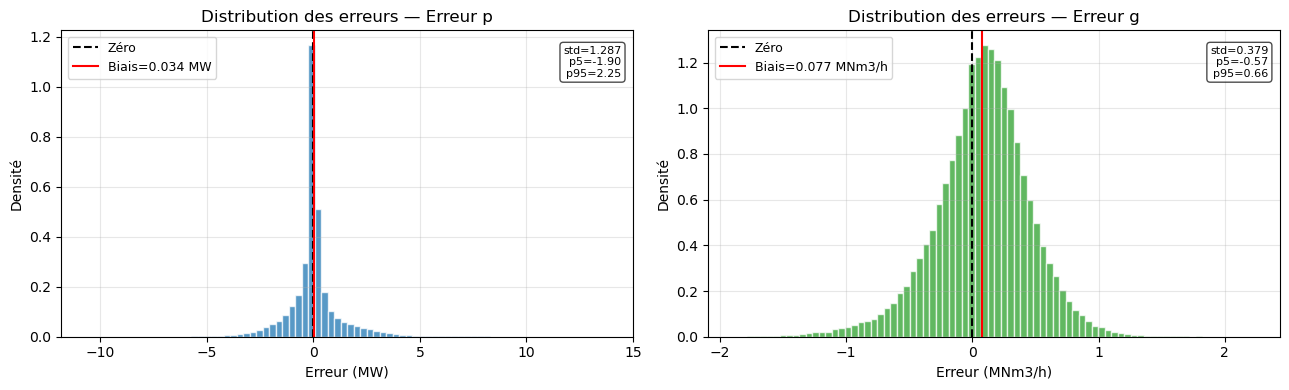

Biais p : 0.0344 MW | Biais g : 0.076546 MNm3/h
Skew  p : 1.008 | Skew g : -0.365


In [20]:
# ============================================================
# CELL 17 — Plot : Distribution des erreurs (p et g)
# ============================================================
err_p = (y_val_pred_p - y_val_true_p).flatten()
err_g = (y_val_pred_g - y_val_true_g).flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, err, label, color, unit in [
    (axes[0], err_p, "Erreur p", "#1f77b4", "MW"),
    (axes[1], err_g, "Erreur g", "#2ca02c", "MNm3/h"),
]:
    ax.hist(err, bins=80, color=color, alpha=0.75, edgecolor="white", density=True)
    ax.axvline(0,        color="black", lw=1.5, ls="--", label="Zéro")
    ax.axvline(err.mean(), color="red", lw=1.5, ls="-",
               label=f"Biais={err.mean():.3f} {unit}")
    ax.set_title(f"Distribution des erreurs — {label}")
    ax.set_xlabel(f"Erreur ({unit})")
    ax.set_ylabel("Densité")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    # Stats texte
    ax.text(0.98, 0.95,
            f"std={err.std():.3f}\np5={np.percentile(err,5):.2f}\np95={np.percentile(err,95):.2f}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8, bbox=dict(boxstyle="round", fc="white", alpha=0.7))

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "04_error_distributions.png"), dpi=130, bbox_inches="tight")
plt.show()

print(f"Biais p : {err_p.mean():.4f} MW | Biais g : {err_g.mean():.6f} MNm3/h")
print(f"Skew  p : {pd.Series(err_p).skew():.3f} | Skew g : {pd.Series(err_g).skew():.3f}")

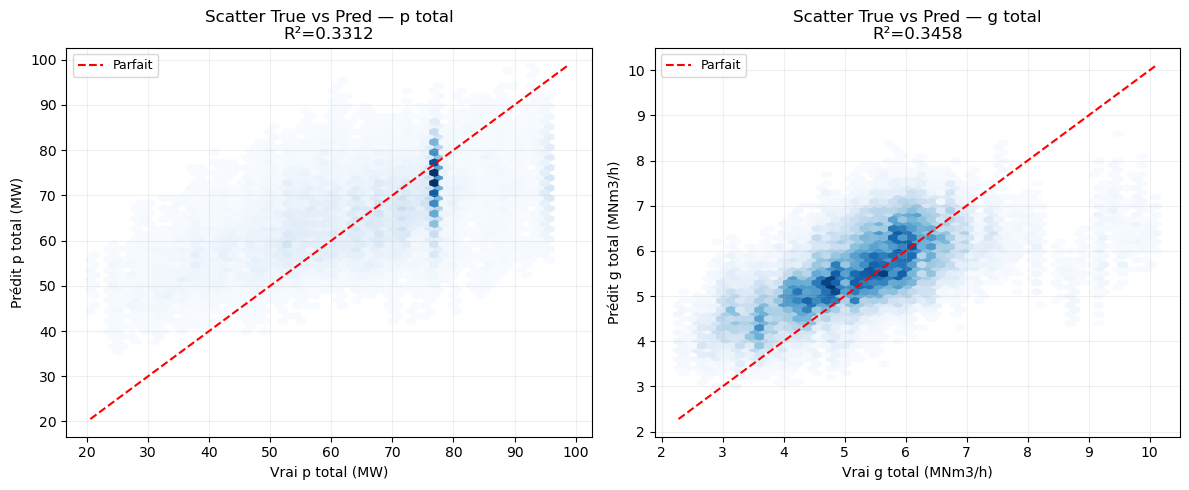

In [21]:
# ============================================================
# CELL 18 — Plot : Scatter True vs Pred (p total et g total)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, true, pred, label, unit, r2 in [
    (axes[0], p_total_true.flatten(), p_total_pred.flatten(),
     "p total", "MW", r2_pt),
    (axes[1], g_total_true.flatten(), g_total_pred.flatten(),
     "g total", "MNm3/h", r2_gt),
]:
    vmin = min(true.min(), pred.min())
    vmax = max(true.max(), pred.max())
    ax.hexbin(true, pred, gridsize=50, cmap="Blues", mincnt=1)
    ax.plot([vmin, vmax], [vmin, vmax], "r--", lw=1.5, label="Parfait")
    ax.set_xlabel(f"Vrai {label} ({unit})")
    ax.set_ylabel(f"Prédit {label} ({unit})")
    ax.set_title(f"Scatter True vs Pred — {label}\nR²={r2:.4f}")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "05_scatter_true_pred.png"), dpi=130, bbox_inches="tight")
plt.show()

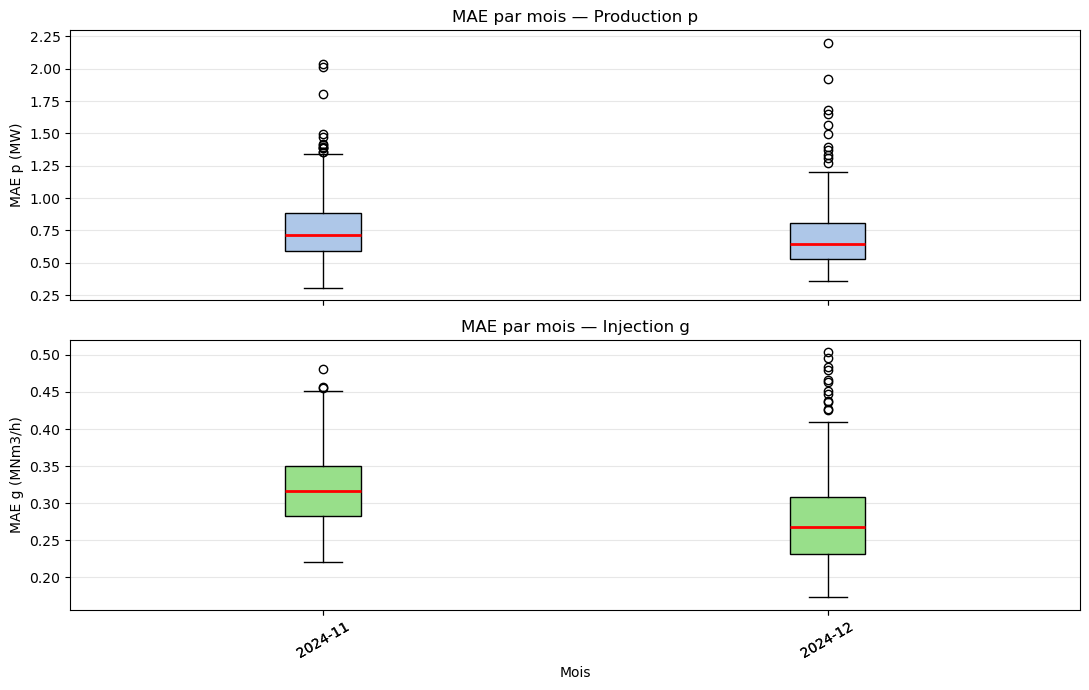

In [22]:
# ============================================================
# CELL 19 — Plot : Boxplot erreur par mois (val set)
# ============================================================
ts_val_pd  = pd.DatetimeIndex(ts_val)
err_p_wins = np.abs(y_val_pred_p - y_val_true_p).mean(axis=1)   # MAE par fenêtre
err_g_wins = np.abs(y_val_pred_g - y_val_true_g).mean(axis=1)

df_err = pd.DataFrame({
    "month"  : ts_val_pd.strftime("%Y-%m"),
    "mae_p"  : err_p_wins,
    "mae_g"  : err_g_wins,
})

months = sorted(df_err["month"].unique())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

data_p = [df_err.loc[df_err["month"]==m, "mae_p"].values for m in months]
data_g = [df_err.loc[df_err["month"]==m, "mae_g"].values for m in months]

bp1 = ax1.boxplot(data_p, labels=months, patch_artist=True,
                  medianprops=dict(color="red", lw=2))
for patch in bp1["boxes"]: patch.set_facecolor("#aec7e8")
ax1.set_ylabel("MAE p (MW)"); ax1.set_title("MAE par mois — Production p")
ax1.grid(True, axis="y", alpha=0.3)

bp2 = ax2.boxplot(data_g, labels=months, patch_artist=True,
                  medianprops=dict(color="red", lw=2))
for patch in bp2["boxes"]: patch.set_facecolor("#98df8a")
ax2.set_ylabel("MAE g (MNm3/h)"); ax2.set_title("MAE par mois — Injection g")
ax2.set_xlabel("Mois"); ax2.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=30)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "06_mae_by_month.png"), dpi=130, bbox_inches="tight")
plt.show()

10 pires fenêtres (RMSE p) :
  Rang |          Date          |  RMSE (MW) |    MAE p |      MAE g
  -----------------------------------------------------------------
     1 |  2024-12-01 00:00:00   |       3.62 |     2.20 |    0.32639
     2 |  2024-11-30 22:00:00   |       3.41 |     2.02 |    0.28649
     3 |  2024-11-30 23:00:00   |       3.37 |     2.04 |    0.31375
     4 |  2024-12-01 01:00:00   |       3.21 |     1.92 |    0.32025
     5 |  2024-11-30 21:00:00   |       3.05 |     1.81 |    0.26300
     6 |  2024-12-01 02:00:00   |       2.85 |     1.68 |    0.28324
     7 |  2024-12-01 03:00:00   |       2.74 |     1.65 |    0.29628
     8 |  2024-11-01 05:00:00   |       2.61 |     1.41 |    0.32743
     9 |  2024-11-01 04:00:00   |       2.58 |     1.35 |    0.35199
    10 |  2024-11-01 08:00:00   |       2.58 |     1.50 |    0.32379


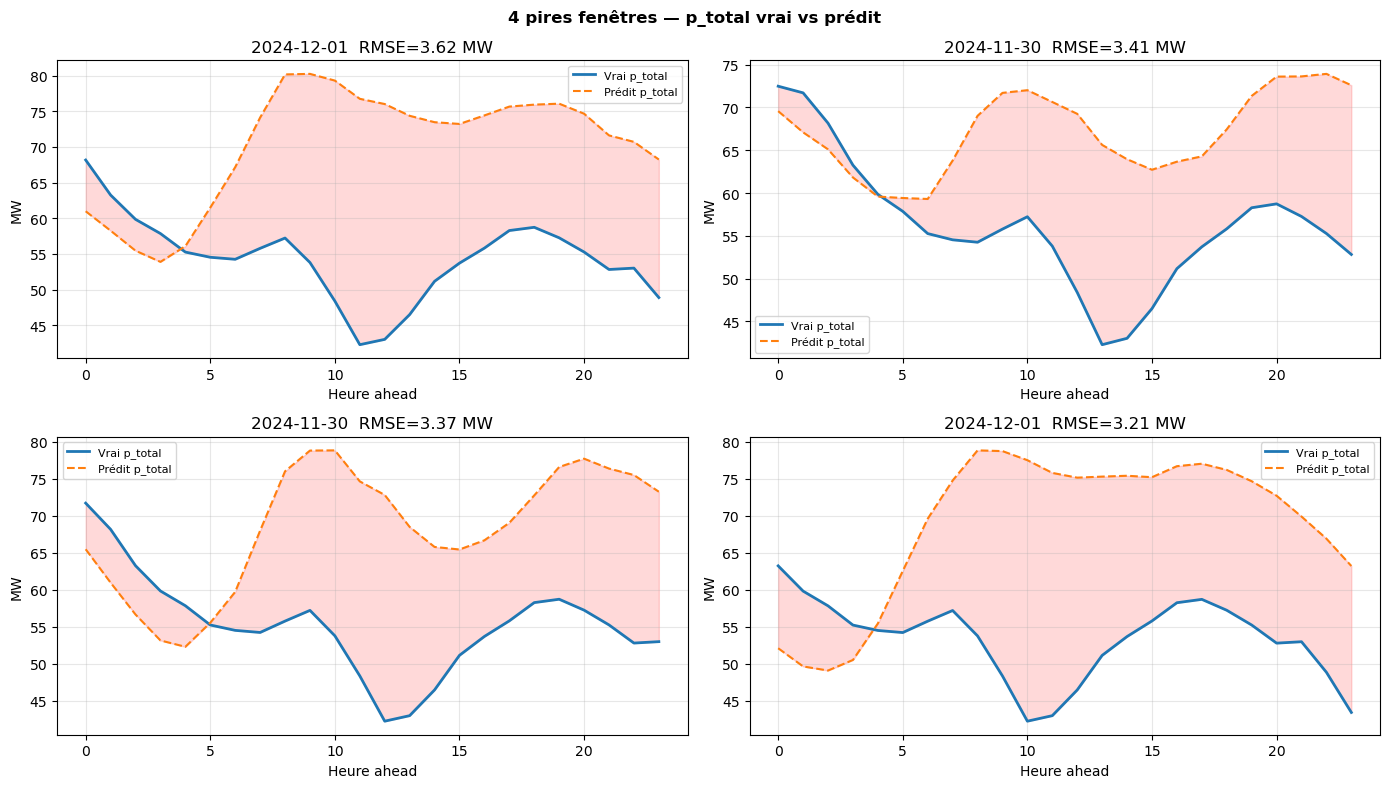

In [23]:
# ============================================================
# CELL 20 — Plot : 10 pires fenêtres détaillées
# ============================================================
window_rmse = np.sqrt(np.mean((y_val_pred_p - y_val_true_p)**2, axis=1))
worst10_idx = np.argsort(window_rmse)[::-1][:10]

print("10 pires fenêtres (RMSE p) :")
print(f"  {'Rang':>4} | {'Date':^22} | {'RMSE (MW)':>10} | {'MAE p':>8} | {'MAE g':>10}")
print("  " + "-" * 65)
for rank, idx in enumerate(worst10_idx, 1):
    mae_p_w = np.abs(y_val_pred_p[idx] - y_val_true_p[idx]).mean()
    mae_g_w = np.abs(y_val_pred_g[idx] - y_val_true_g[idx]).mean()
    print(f"  {rank:>4} | {str(pd.Timestamp(ts_val[idx]))[:19]:^22} | "
          f"{window_rmse[idx]:>10.2f} | {mae_p_w:>8.2f} | {mae_g_w:>10.5f}")

# Visualiser les 4 pires
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, idx in zip(axes.flatten(), worst10_idx[:4]):
    hours = range(HZ)
    p_true_w = p_true_3d[idx].sum(-1)   # (24,)
    p_pred_w = p_pred_3d[idx].sum(-1)
    ax.plot(hours, p_true_w, lw=2, label="Vrai p_total",   color="#1f77b4")
    ax.plot(hours, p_pred_w, lw=1.5, ls="--", label="Prédit p_total", color="#ff7f0e")
    ax.fill_between(hours, p_true_w, p_pred_w, alpha=0.15, color="red")
    ax.set_title(f"{str(pd.Timestamp(ts_val[idx]))[:10]}  "
                 f"RMSE={window_rmse[idx]:.2f} MW")
    ax.set_xlabel("Heure ahead"); ax.set_ylabel("MW")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle("4 pires fenêtres — p_total vrai vs prédit", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "07_worst_windows.png"), dpi=130, bbox_inches="tight")
plt.show()

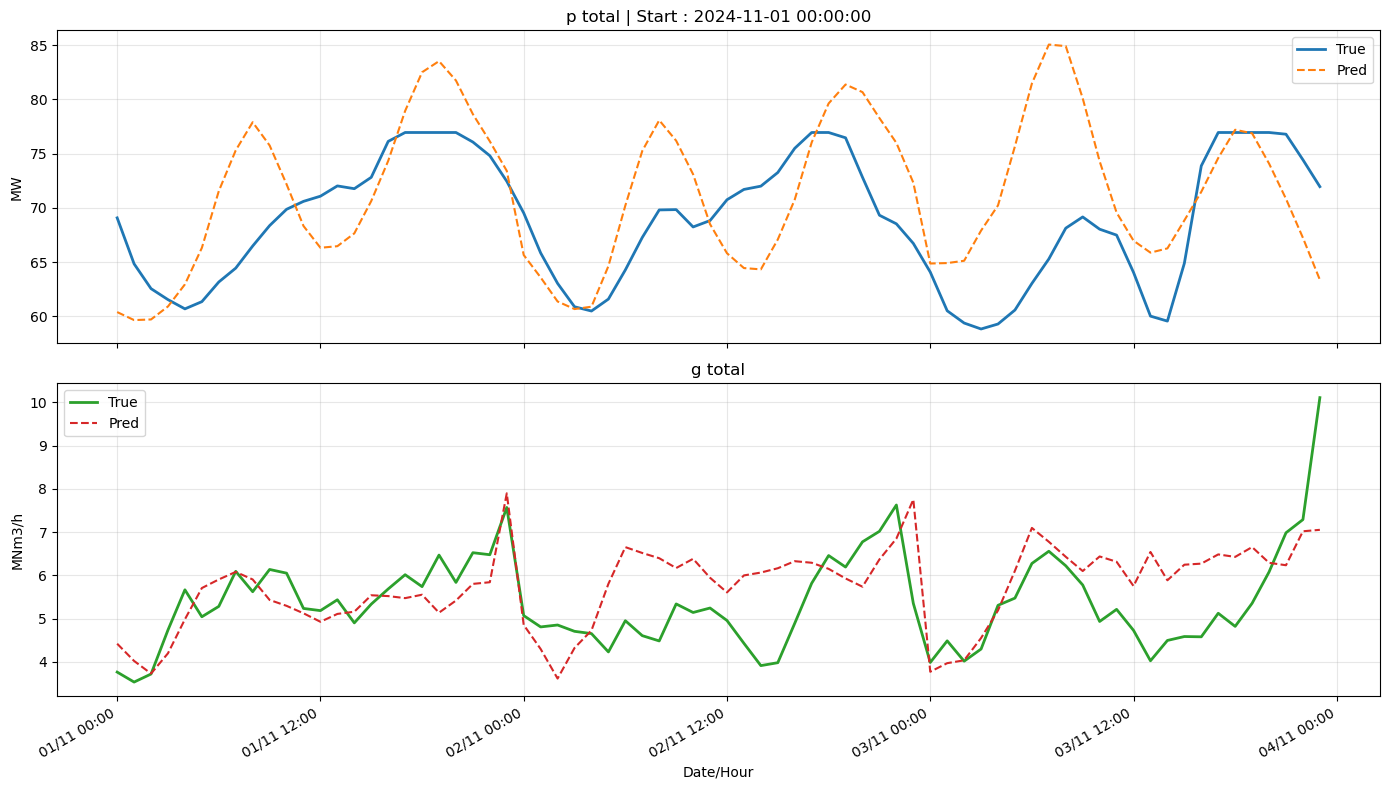

In [24]:
# ============================================================
# CELL 21 — Plot : Rolling 72h (3 jours)
# ============================================================
ALIGN_TS = "2024-11-01 00:00:00"
N_DAYS   = 3

align_pd   = pd.Timestamp(ALIGN_TS)
mask_align = pd.DatetimeIndex(ts_val) >= align_pd
t0_start   = int(np.argmax(mask_align)) if mask_align.any() else 0
#n_win      = min(N_DAYS, len(ts_val) - t0_start)
n_win = min(N_DAYS, (len(ts_val) - t0_start + HZ - 1) // HZ)
all_hours  = N_DAYS * HZ
ts_base    = pd.date_range(start=align_pd, periods=all_hours, freq="h")

p_t = np.zeros(all_hours); p_p = np.zeros(all_hours)
g_t = np.zeros(all_hours); g_p = np.zeros(all_hours)

for day in range(n_win):
    #idx = t0_start + day
    idx = t0_start + day * HZ
    if idx >= len(ts_val): break
    hs, he = day*HZ, (day+1)*HZ
    p_t[hs:he] = p_total_true[idx];  p_p[hs:he] = p_total_pred[idx]
    g_t[hs:he] = g_total_true[idx];  g_p[hs:he] = g_total_pred[idx]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(ts_base, p_t, label="True",   lw=2,   color="#1f77b4")
ax1.plot(ts_base, p_p, label="Pred", lw=1.5, color="#ff7f0e", ls="--")
#ax1.fill_between(ts_base, p_t, p_p, alpha=0.1, color="#d62728")
#for d in [1, 2]:
    #ax1.axvline(ts_base[d*HZ], color="gray", lw=1, ls=":", label="J+1/J+2" if d==1 else "")
ax1.set_ylabel("MW"); ax1.set_title(f"p total | Start : {ALIGN_TS}")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ts_base, g_t, label="True",   lw=2,   color="#2ca02c")
ax2.plot(ts_base, g_p, label="Pred", lw=1.5, color="#d62728", ls="--")
#ax2.fill_between(ts_base, g_t, g_p, alpha=0.1, color="#d62728")
#for d in [1, 2]:
    #ax2.axvline(ts_base[d*HZ], color="gray", lw=1, ls=":")
ax2.set_ylabel("MNm3/h"); ax2.set_xlabel("Date/Hour")
ax2.set_title("g total")
ax2.legend(); ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:00"))
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "08_rolling_72h.png"), dpi=130, bbox_inches="tight")
plt.show()

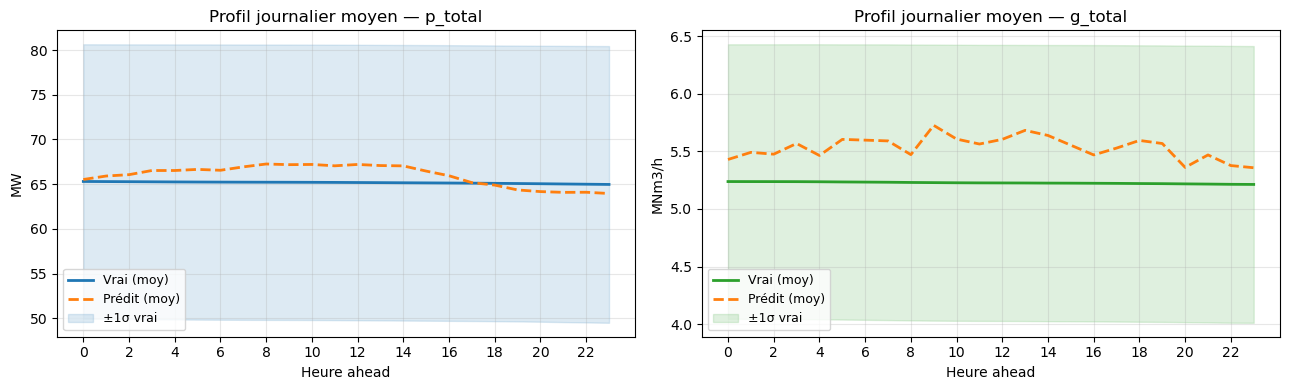

In [25]:
# ============================================================
# CELL 22 — Plot : Profil moyen vrai vs prédit (heure du jour)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, true_h, pred_h, label, unit, color in [
    (axes[0], p_total_true, p_total_pred, "p_total", "MW", "#1f77b4"),
    (axes[1], g_total_true, g_total_pred, "g_total", "MNm3/h", "#2ca02c"),
]:
    mean_true = true_h.mean(axis=0)   # (24,)
    mean_pred = pred_h.mean(axis=0)
    std_true  = true_h.std(axis=0)

    hours = range(HZ)
    ax.plot(hours, mean_true, lw=2, color=color,   label="Vrai (moy)")
    ax.plot(hours, mean_pred, lw=2, color="#ff7f0e", ls="--", label="Prédit (moy)")
    ax.fill_between(hours, mean_true-std_true, mean_true+std_true,
                    alpha=0.15, color=color, label="±1σ vrai")
    ax.set_title(f"Profil journalier moyen — {label}")
    ax.set_xlabel("Heure ahead"); ax.set_ylabel(unit)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, HZ, 2))

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "09_daily_profile.png"), dpi=130, bbox_inches="tight")
plt.show()

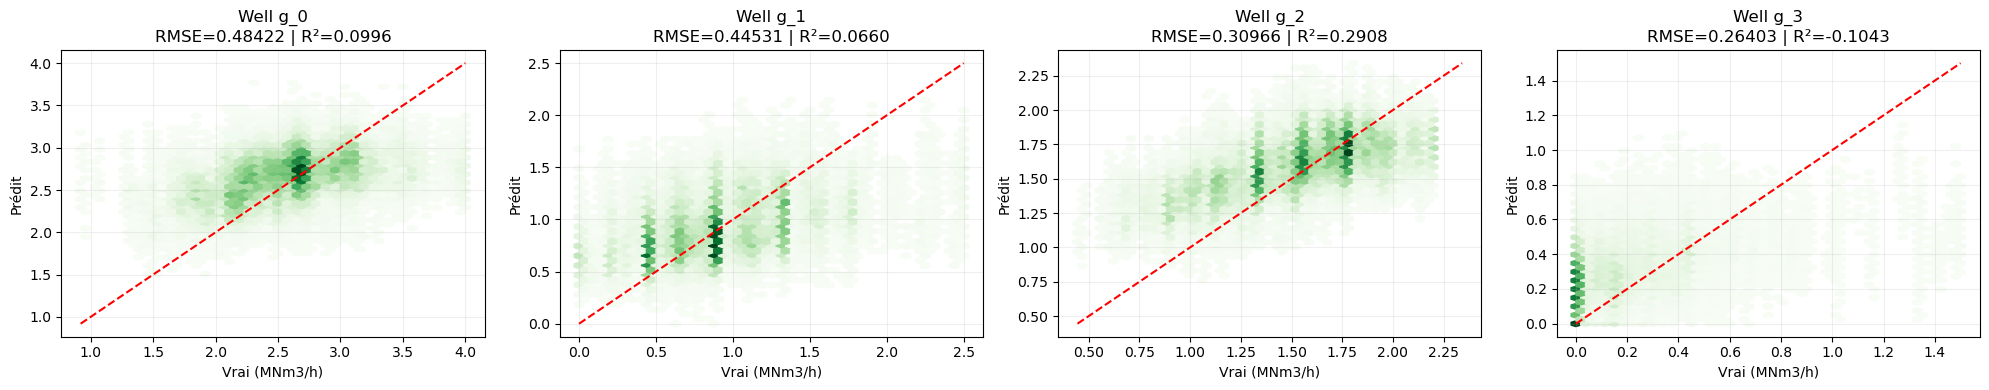

RMSE par well :
  Well g_0 : 0.484222 MNm3/h
  Well g_1 : 0.445313 MNm3/h
  Well g_2 : 0.309661 MNm3/h
  Well g_3 : 0.264035 MNm3/h


In [26]:
# ============================================================
# CELL 23 — Plot : Diagnostic détaillé wells (g)
# ============================================================
rmse_per_well = np.sqrt(np.mean((g_pred_3d - g_true_3d)**2, axis=(0,1)))  # (G,)

fig, axes = plt.subplots(1, G_, figsize=(5*G_, 4))
if G_ == 1: axes = [axes]

for i, ax in enumerate(axes):
    true_w = g_true_3d[:,:,i].flatten()
    pred_w = g_pred_3d[:,:,i].flatten()
    ax.hexbin(true_w, pred_w, gridsize=40, cmap="Greens", mincnt=1)
    vmin = min(true_w.min(), pred_w.min())
    vmax = max(true_w.max(), pred_w.max())
    ax.plot([vmin,vmax],[vmin,vmax],"r--",lw=1.5)
    r2_w = r2_score(true_w, pred_w)
    ax.set_title(f"Well g_{i}\nRMSE={rmse_per_well[i]:.5f} | R²={r2_w:.4f}")
    ax.set_xlabel("Vrai (MNm3/h)"); ax.set_ylabel("Prédit")
    ax.grid(True, alpha=0.2)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "10_wells_scatter.png"), dpi=130, bbox_inches="tight")
plt.show()

print("RMSE par well :")
for i, r in enumerate(rmse_per_well):
    print(f"  Well g_{i} : {r:.6f} MNm3/h")

  Unité Type    MAE   RMSE      R²
 GFPP_5    p 2.4540 3.3716  0.3548
GFPP_21    p 1.9084 2.4029  0.7465
 GFPP_2    p 1.7366 2.1917  0.7597
 GFPP_3    p 1.4183 1.8101  0.3765
 GFPP_8    p 1.3720 1.6922  0.3751
GFPP_18    p 1.3634 1.6825  0.3993
GFPP_14    p 1.0895 1.4058  0.3198
 GFPP_0    p 1.0559 1.3075  0.3879
GFPP_16    p 0.7896 1.1173  0.3062
GFPP_22    p 0.5917 0.9927  0.2532
 GFPP_7    p 0.5324 0.9658  0.1701
GFPP_13    p 0.5605 0.8289  0.2983
 GFPP_9    p 0.4832 0.6527  0.3295
GFPP_11    p 0.4193 0.5595  0.3230
 Well_0    g 0.3805 0.4842  0.0996
 Well_1    g 0.3515 0.4453  0.0660
GFPP_17    p 0.2704 0.4116  0.2773
GFPP_20    p 0.3009 0.4029  0.3274
GFPP_10    p 0.2592 0.3193  0.3632
 Well_2    g 0.2488 0.3097  0.2908
 Well_3    g 0.2047 0.2640 -0.1043
 GFPP_1    p 0.1378 0.1850  0.3083
GFPP_12    p 0.1309 0.1813  0.3185
GFPP_23    p 0.1228 0.1651  0.3169
GFPP_19    p 0.0407 0.1496 -0.0063
 GFPP_4    p 0.0943 0.1385  0.2973
 GFPP_6    p 0.0041 0.0172 -0.0093
GFPP_15    p 0.0009 

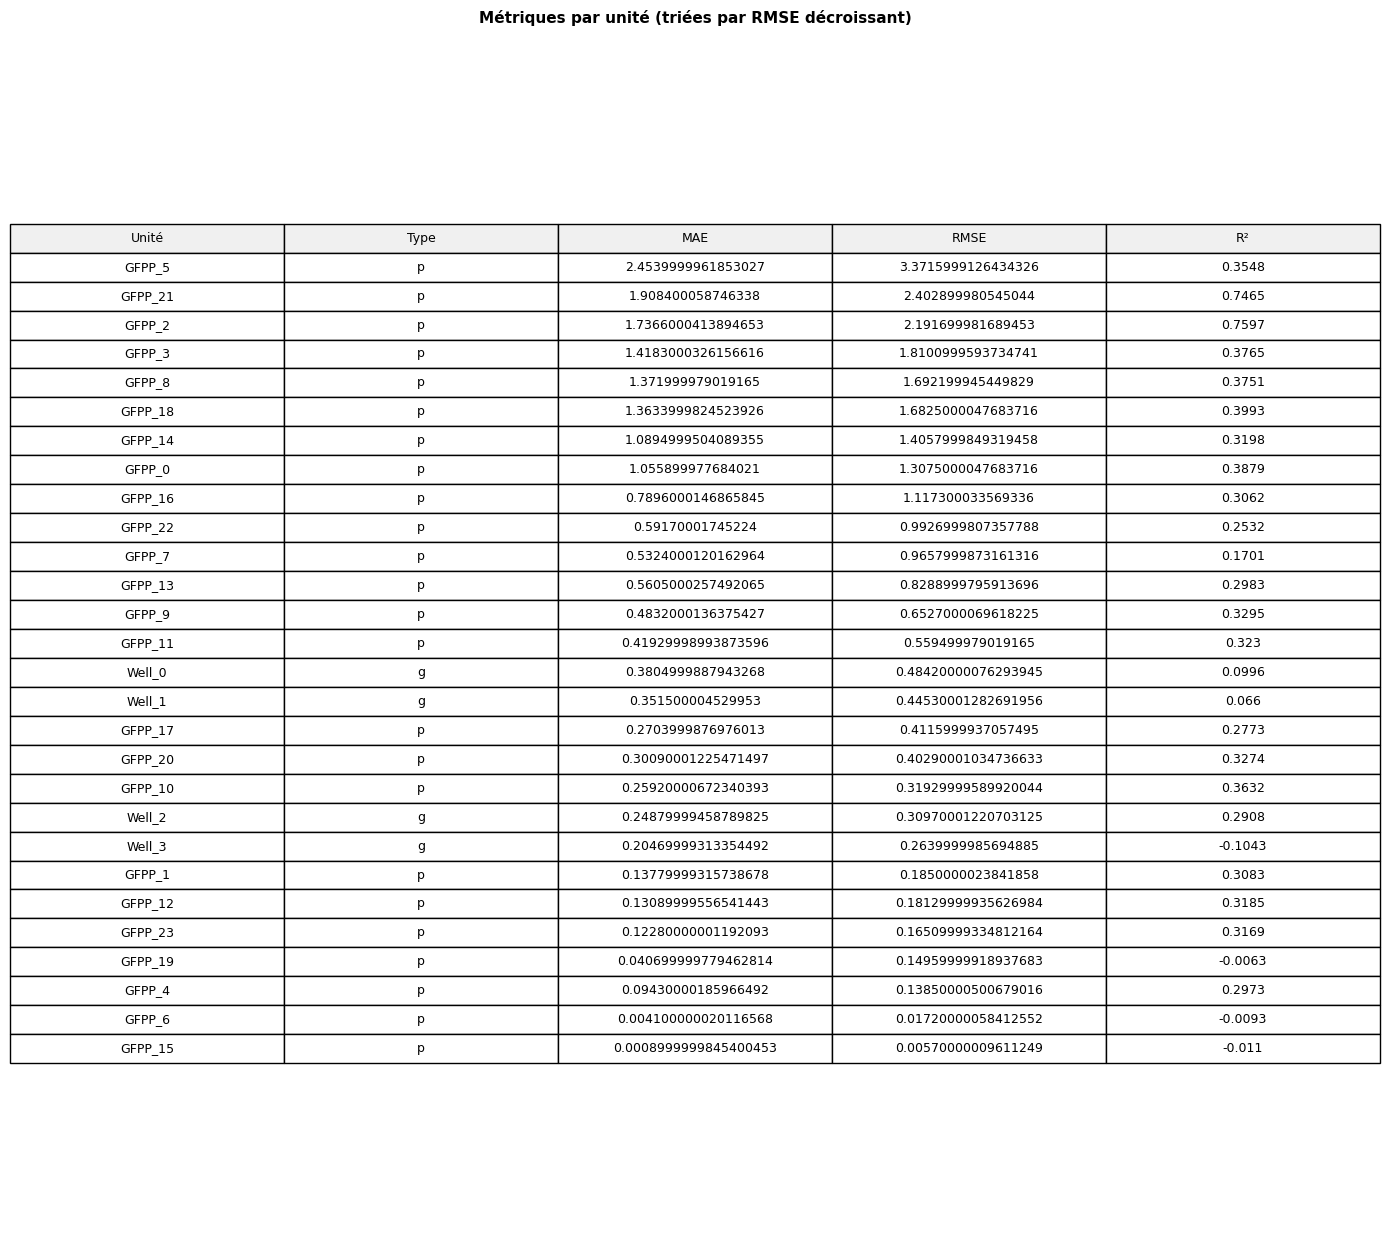

In [27]:
# ============================================================
# CELL 24 — Tableau récapitulatif final
# ============================================================
rows = []
for i in range(P_):
    true_i = p_true_3d[:,:,i].flatten()
    pred_i = p_pred_3d[:,:,i].flatten()
    mae_i  = np.abs(true_i - pred_i).mean()
    rmse_i = np.sqrt(np.mean((true_i - pred_i)**2))
    r2_i   = r2_score(true_i, pred_i)
    rows.append({"Unité": f"GFPP_{i}", "Type":"p", "MAE":mae_i, "RMSE":rmse_i, "R²":r2_i})

for i in range(G_):
    true_i = g_true_3d[:,:,i].flatten()
    pred_i = g_pred_3d[:,:,i].flatten()
    mae_i  = np.abs(true_i - pred_i).mean()
    rmse_i = np.sqrt(np.mean((true_i - pred_i)**2))
    r2_i   = r2_score(true_i, pred_i)
    rows.append({"Unité": f"Well_{i}", "Type":"g", "MAE":mae_i, "RMSE":rmse_i, "R²":r2_i})

df_summary = pd.DataFrame(rows).sort_values("RMSE", ascending=False)
df_summary["MAE"]  = df_summary["MAE"].round(4)
df_summary["RMSE"] = df_summary["RMSE"].round(4)
df_summary["R²"]   = df_summary["R²"].round(4)

print(df_summary.to_string(index=False))
df_summary.to_csv(os.path.join(OUT_DIR, "metrics_per_unit.csv"), index=False)
print(f"\n✓ Sauvegardé : {OUT_DIR}/metrics_per_unit.csv")

# Visualisation
fig, ax = plt.subplots(figsize=(14, 0.4 * len(df_summary) + 1.5))
ax.axis("off")
tbl = ax.table(
    cellText=df_summary.values, colLabels=df_summary.columns,
    cellLoc="center", loc="center",
    colColours=["#f0f0f0"]*len(df_summary.columns)
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.scale(1, 1.4)
ax.set_title("Métriques par unité (triées par RMSE décroissant)",
             fontsize=11, fontweight="bold", pad=10)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "11_metrics_table.png"), dpi=130, bbox_inches="tight")
plt.show()

=== JOINT | Global metrics on validation ===
--- p_total ---
MAE            : 9.912623
RMSE           : 12.596027
MAE/mean       : 0.152104
Roughness err  : 0.866488
Roughness true : 3.078375
Roughness pred : 2.211887

--- g_total ---
MAE            : 0.752910
RMSE           : 0.968533
MAE/mean       : 0.144047
Roughness err  : 0.275253
Roughness true : 0.615804
Roughness pred : 0.340551


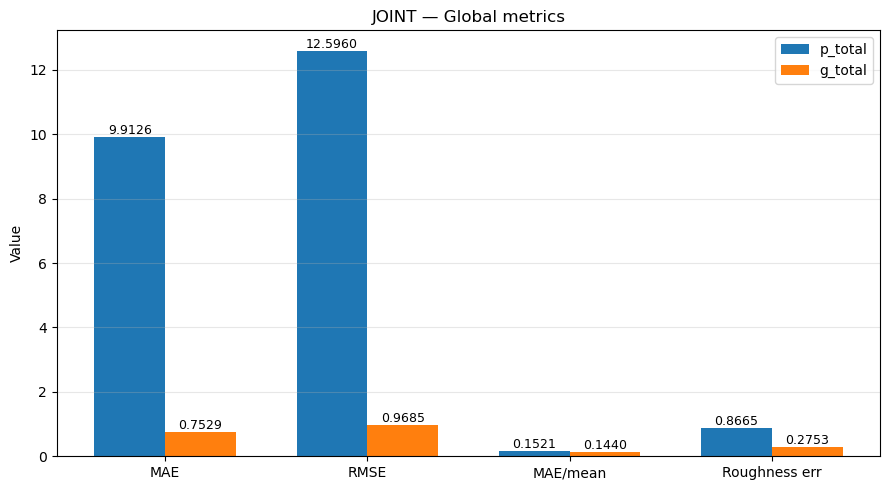

Figure saved to: ./runs_mlp_pg\global_metrics_joint.png


In [28]:
# ============================================================
# CELL — Global metrics plot | GAZ + ELEC (JOINT)
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def roughness(x):
    x = np.asarray(x).reshape(-1)
    if len(x) < 2:
        return 0.0
    return float(np.mean(np.abs(np.diff(x))))

# ------------------------------------------------------------
# Prédictions globales sur le set de validation
# ------------------------------------------------------------
model.eval()
with torch.no_grad():
    pred_s = model(torch.from_numpy(X_val_s).to(DEVICE)).cpu().numpy()

# séparation p / g
pred_p_s = pred_s[:, :p_dim]
pred_g_s = pred_s[:, p_dim:]

# retour échelle réelle
pred_p = scaler_y_p.inverse_transform(pred_p_s)   # shape: (N, 24*P)
pred_g = scaler_y_g.inverse_transform(pred_g_s)   # shape: (N, 24*G)

true_p = y_val_p
true_g = y_val_g

P = meta["P"]
G = meta["G"]
H = HORIZON_HOURS

pred_p_3d = pred_p.reshape(-1, H, P)
true_p_3d = true_p.reshape(-1, H, P)

pred_g_3d = pred_g.reshape(-1, H, G)
true_g_3d = true_g.reshape(-1, H, G)

# totals
p_pred_total = pred_p_3d.sum(axis=2).reshape(-1)
p_true_total = true_p_3d.sum(axis=2).reshape(-1)

g_pred_total = pred_g_3d.sum(axis=2).reshape(-1)
g_true_total = true_g_3d.sum(axis=2).reshape(-1)

# ------------------------------------------------------------
# Metrics p_total
# ------------------------------------------------------------
p_mae       = mae(p_true_total, p_pred_total)
p_rmse      = rmse(p_true_total, p_pred_total)
p_mae_mean  = p_mae / (np.mean(np.abs(p_true_total)) + 1e-12)
p_rough_t   = roughness(p_true_total)
p_rough_p   = roughness(p_pred_total)
p_rough_err = abs(p_rough_p - p_rough_t)

# ------------------------------------------------------------
# Metrics g_total
# ------------------------------------------------------------
g_mae       = mae(g_true_total, g_pred_total)
g_rmse      = rmse(g_true_total, g_pred_total)
g_mae_mean  = g_mae / (np.mean(np.abs(g_true_total)) + 1e-12)
g_rough_t   = roughness(g_true_total)
g_rough_p   = roughness(g_pred_total)
g_rough_err = abs(g_rough_p - g_rough_t)

print("=== JOINT | Global metrics on validation ===")
print("--- p_total ---")
print(f"MAE            : {p_mae:.6f}")
print(f"RMSE           : {p_rmse:.6f}")
print(f"MAE/mean       : {p_mae_mean:.6f}")
print(f"Roughness err  : {p_rough_err:.6f}")
print(f"Roughness true : {p_rough_t:.6f}")
print(f"Roughness pred : {p_rough_p:.6f}")

print("\n--- g_total ---")
print(f"MAE            : {g_mae:.6f}")
print(f"RMSE           : {g_rmse:.6f}")
print(f"MAE/mean       : {g_mae_mean:.6f}")
print(f"Roughness err  : {g_rough_err:.6f}")
print(f"Roughness true : {g_rough_t:.6f}")
print(f"Roughness pred : {g_rough_p:.6f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
metric_names = ["MAE", "RMSE", "MAE/mean", "Roughness err"]
p_values = [p_mae, p_rmse, p_mae_mean, p_rough_err]
g_values = [g_mae, g_rmse, g_mae_mean, g_rough_err]

x = np.arange(len(metric_names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, p_values, width=w, label="p_total")
bars2 = ax.bar(x + w/2, g_values, width=w, label="g_total")

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_title("JOINT — Global metrics")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h, f"{h:.4f}",
                ha="center", va="bottom", fontsize=9)

fig.tight_layout()

save_path = os.path.join(OUT_DIR, "global_metrics_joint.png")
fig.savefig(save_path, dpi=140, bbox_inches="tight")
plt.show()

print("Figure saved to:", save_path)

In [29]:
print(p_true_3d.shape)
print(np.mean(p_true_3d))
print(np.min(p_true_3d), np.max(p_true_3d))

(1441, 24, 24)
2.7154236
0.0 20.0


Shape p_all : (8784, 24)

Nombre d'événements détectés par GFPP :
0       0
1       0
2       2
3       0
4       0
5     201
6       0
7       0
8       0
9       0
10      0
11      0
12      0
13      0
14      0
15      0
16      0
17      0
18      0
19      0
20      0
21      2
22      0
23      0
dtype: int64


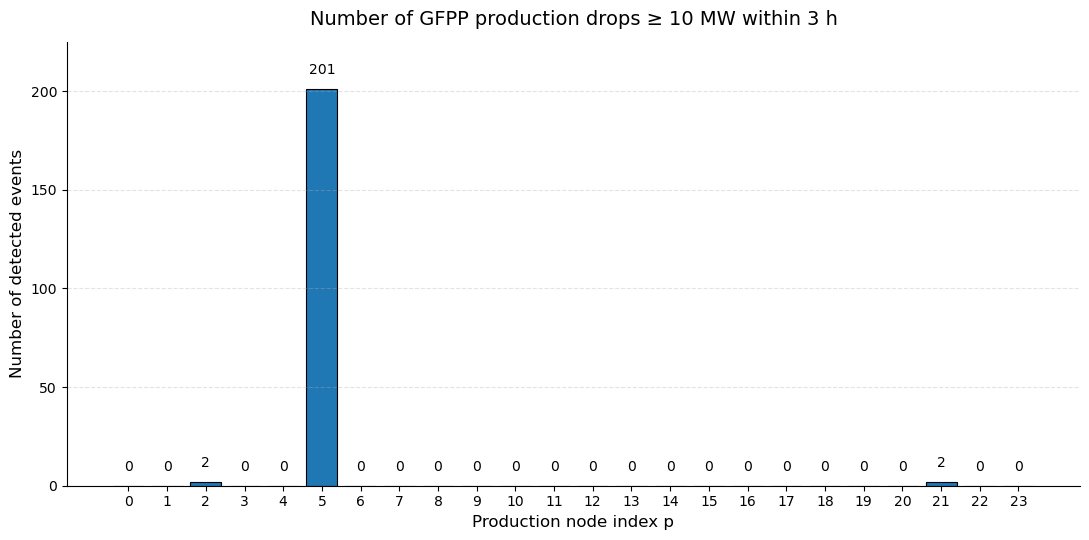

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMÈTRES À MODIFIER
# =========================

excel_path = "./output/Decision_variablesRU.xlsx"   # adapte si nécessaire

# Mets ici les indices des nœuds p qui correspondent aux GFPP
gfpp_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]   # <-- à remplacer par tes vrais indices GFPP

drop_threshold_mw = 10.0   # chute minimale
recovery_threshold_mw = 10.0  # remontée minimale avant de recompter
max_horizon_h = 3
time_step_h = 1  # 1 ligne = 1 heure

# =========================
# LECTURE ET CONCATÉNATION
# =========================

xls = pd.ExcelFile(excel_path)

p_sheets = [s for s in xls.sheet_names if s.startswith("p-") and s.endswith("-2024")]
p_sheets = sorted(p_sheets, key=lambda x: int(x.split("-")[1]))

dfs = []
for sheet in p_sheets:
    df = pd.read_excel(excel_path, sheet_name=sheet, index_col=0)
    dfs.append(df)

p_all = pd.concat(dfs, axis=0, ignore_index=True)

try:
    p_all.columns = [int(c) for c in p_all.columns]
except:
    pass

print("Shape p_all :", p_all.shape)

# =========================
# FONCTION DE COMPTAGE
# =========================

def count_drop_events_with_recovery(series, drop_threshold=5.0, recovery_threshold=5.0, max_horizon_steps=3):
    """
    Compte les événements où la série perd au moins `drop_threshold`
    en `max_horizon_steps` ou moins.

    Après détection d'un événement, on bloque tout nouveau comptage
    jusqu'à ce que la série remonte d'au moins `recovery_threshold`
    par rapport au minimum atteint pendant la chute.
    """
    s = pd.to_numeric(series, errors="coerce").reset_index(drop=True)

    n_events = 0
    t = 0
    state = "ready"   # "ready" ou "waiting_recovery"
    trough_value = None

    while t < len(s) - 1:
        if pd.isna(s.iloc[t]):
            t += 1
            continue

        if state == "ready":
            current_val = s.iloc[t]

            event_found = False
            best_h = None
            best_future_val = None

            # on cherche une chute >= seuil dans les prochaines heures
            for h in range(1, max_horizon_steps + 1):
                if t + h >= len(s):
                    break
                future_val = s.iloc[t + h]
                if pd.isna(future_val):
                    continue

                if current_val - future_val >= drop_threshold:
                    event_found = True
                    best_h = h
                    best_future_val = future_val
                    break

            if event_found:
                n_events += 1
                state = "waiting_recovery"

                # on initialise le point bas avec la valeur qui a déclenché l'événement
                trough_value = best_future_val

                # on saute directement au point de chute détecté
                t = t + best_h
            else:
                t += 1

        elif state == "waiting_recovery":
            current_val = s.iloc[t]

            if not pd.isna(current_val):
                trough_value = min(trough_value, current_val)

                # tant qu'on n'a pas regagné 5 MW depuis le creux, on reste bloqué
                if current_val - trough_value >= recovery_threshold:
                    state = "ready"
                    trough_value = None

            t += 1

    return n_events

# =========================
# COMPTAGE PAR GFPP
# =========================

max_horizon_steps = int(max_horizon_h / time_step_h)
counts = {}

for idx in gfpp_indices:
    if idx not in p_all.columns:
        print(f"Attention : l'indice {idx} n'existe pas dans les colonnes.")
        continue

    counts[idx] = count_drop_events_with_recovery(
        p_all[idx],
        drop_threshold=drop_threshold_mw,
        recovery_threshold=recovery_threshold_mw,
        max_horizon_steps=max_horizon_steps
    )

count_series = pd.Series(counts).sort_index()

print("\nNombre d'événements détectés par GFPP :")
print(count_series)

# =========================
# PLOT
# =========================

plt.figure(figsize=(11, 5.5))

bars = plt.bar(
    count_series.index.astype(str),
    count_series.values,
    edgecolor="black",
    linewidth=0.8
)

plt.title(
    f"Number of GFPP production drops ≥ {drop_threshold_mw:.0f} MW within {max_horizon_h} h",
    fontsize=14,
    pad=12
)
plt.xlabel("Production node index p", fontsize=12)
plt.ylabel("Number of detected events", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

ymax = count_series.max()
plt.ylim(0, ymax + max(1, 0.12 * ymax))

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.03 * max(1, ymax),
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()